### 1. Data Loading

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

In [ ]:
# 1. Load the files
try:
    compounds = pd.read_csv('MBMB_COMPOUND.csv', encoding='utf-8-sig')
    transactions = pd.read_csv('MBMB_PARKING_FINAL.csv', encoding='utf-8-sig')
    print("Source files loaded successfully.")
except Exception as e:
    print(f"Error loading files: {e}")

print("Preprocessing plate numbers and date fields...")

/tmp/ipykernel_9527/1852123378.py:3: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  compounds = pd.read_csv('MBMB_COMPOUND.csv', encoding='utf-8-sig')
/tmp/ipykernel_9527/1852123378.py:4: DtypeWarning: Columns (0,17) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('MBMB_PARKING_FINAL.csv', encoding='utf-8-sig')


Source files loaded successfully.
Preprocessing plate numbers and date fields...


### 2. Data Cleaning

In [ ]:
# 2. Standardize plate numbers
def get_match_key(plate):
    if pd.isna(plate):
        return ""
    return str(plate).upper().replace(' ', '').replace('*', '')

compounds['match_key'] = compounds['plate_number'].apply(get_match_key)
transactions['match_key'] = transactions['plate_number'].apply(get_match_key)

# Exclude empty plate values or keys that are too short (less than 3 characters)
compounds = compounds[compounds['match_key'].str.len() >= 3]
transactions = transactions[transactions['match_key'].str.len() >= 3]

In [ ]:
# 3. Synchronize Datetime columns (using dayfirst=True for local dates)
comp_time = pd.to_datetime(compounds['trkhkmp'], dayfirst=True, errors='coerce')
trans_time = pd.to_datetime(transactions['created_at'], dayfirst=True, errors='coerce')

# Extract exact dates (YYYY-MM-DD) for synchronizing
compounds['match_date'] = comp_time.dt.date
transactions['match_date'] = trans_time.dt.date

# Drop rows where date parsing failed
compounds_valid = compounds.dropna(subset=['match_date']).copy()
transactions_valid = transactions.dropna(subset=['match_date']).copy()

In [ ]:
# 4. Filter Compounds by the three non-payment violations
allowed_violations = [
    "MELETAK KERETA DIPETAK LETAK KERETA TANPA BAYARAN CAJ YANG DITETAPKAN",
    "GAGAL MEMATUHI SYARAT-SYARAT YANG DINYATAKAN PADA KUPON LETAK KERETA",
    "Kenderaan Motor Yang Diletakan secara Berterusan Selama lebih dari 1 hari di tempat letak kereta apabila tempoh letak kereta tamat"
]
compounds_valid['prgnsalah_clean'] = compounds_valid['prgnsalah'].astype(str).str.strip().str.upper()
allowed_violations_clean = [v.strip().upper() for v in allowed_violations]
comp_filtered = compounds_valid[compounds_valid['prgnsalah_clean'].isin(allowed_violations_clean)].copy()
comp_filtered = comp_filtered.drop(columns=['prgnsalah_clean'])

In [ ]:
# 5. Filter Transactions to "Hourly" only
trans_filtered = transactions_valid[transactions_valid['product_type'].astype(str).str.strip().str.upper() == 'HOURLY'].copy()

print(f"Filtered compounds (non-payment): {len(comp_filtered)} rows.")
print(f"Filtered transactions (Hourly only): {len(trans_filtered)} rows.")

Filtered compounds (non-payment): 63822 rows.
Filtered transactions (Hourly only): 1033006 rows.


In [ ]:
# 6. Drop columns as requested to keep the file size compact
columns_to_drop_compounds = [
    'jeniskmp', 'nokompaun', 'no_kp', 'nosyarikat', 'namasyarikat', 'namapelanggar',
    'alamat2', 'alamat3', 'kodhasil', 'kodori', 'butirsalah', 'prgnakta', 'kodpguatkuasa',
    'namapenguatkuasa', 'noicpenguatkuasa', 'nocukaijalan', 'nopetak', 'namasaksi',
    'kodsaksi', 'prgnjabatan', 'kodjabatan', 'amnkurang', 'amnt7', 'discount_stat', 'source'
]

columns_to_drop_transactions = [
    'name', 'email', 'extend', 'parent_transaction_id', 'provider',
    'provider_transaction_id', 'platform', 'whatsapp_notification', 'email_notification'
]

comp_lite = comp_filtered.drop(columns=columns_to_drop_compounds, errors='ignore').copy()
trans_lite = trans_filtered.drop(columns=columns_to_drop_transactions, errors='ignore').copy()

### 3. Data Merging

In [ ]:
# 7. Perform same-day synchronized join
# Merging on BOTH match_key (license plate) and match_date (same day)
print("Performing same-day synchronized merge...")
matched_df = pd.merge(
    comp_lite,
    trans_lite,
    on=['match_key', 'match_date'],
    suffixes=('_compound', '_transaction')
)

# Sort results by plate and date so identical vehicles are grouped together
matched_df = matched_df.sort_values(by=['match_key', 'match_date'])

# Format columns for clear verification
matched_df = matched_df.rename(columns={'match_key': 'matched_plate_key', 'match_date': 'synchronized_date'})
cols = ['matched_plate_key', 'synchronized_date', 'plate_number_compound', 'plate_number_transaction'] + [
    col for col in matched_df.columns if col not in ['matched_plate_key', 'synchronized_date', 'plate_number_compound', 'plate_number_transaction']
]
matched_df = matched_df[cols]

# Drop entirely empty columns if any remain
initial_col_count = len(matched_df.columns)
matched_df = matched_df.dropna(how='all', axis=1)
final_col_count = len(matched_df.columns)
print(f"Dropped {initial_col_count - final_col_count} completely empty columns.")

Performing same-day synchronized merge...
Dropped 1 completely empty columns.


### 4. Cleaned Data Export

In [ ]:
# 8. Export result to CSV
output_file = 'plate_match_verification_results.csv'
print(f"Saving same-day matched records to: {output_file}...")
matched_df.to_csv(output_file, index=False)

print(f"\nSuccess. Found {len(matched_df)} matched rows on matching dates.")

Saving same-day matched records to: plate_match_verification_results.csv...

Success. Found 1871 matched rows on matching dates.


### 5. Data Checking (From Friend)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load friend's matched file
friend_df = pd.read_csv('plate_match_verification_results.csv',
                         encoding='utf-8-sig', low_memory=False)


print("=== Cleaned file ===")
print(f"Rows    : {len(friend_df):,}")
print(f"Columns : {friend_df.columns.tolist()}")

=== Cleaned file ===
Rows    : 1,871
Columns : ['matched_plate_key', 'synchronized_date', 'plate_number_compound', 'plate_number_transaction', 'majid', 'prgnsalah', 'prgnkaw', 'prgnjalan', 'prgnwarna', 'prgnjenken', 'prgnkodken', 'trkhkmp', 'amnkmp', 'prgntrfkmp', 'tempatjadi', 'amnkmp2', 'amnkmp3', 'amnterkini', 'trkhkmpyy', 'council', 'zone', 'started_at', 'expired_at', 'minute', 'product_name', 'product_type', 'price', 'created_at', 'updated_at', 'road_name']


In [ ]:
# ── See what columns friend has ───────────────────────────────
print("=== Friend's file column details ===\n")
for i, col in enumerate(friend_df.columns, 1):
    sample   = friend_df[col].dropna().iloc[0] \
               if friend_df[col].notna().any() else 'ALL NULL'
    null_pct = friend_df[col].isna().mean() * 100
    print(f"{i:3}. {col:40} | "
          f"sample: {str(sample)[:20]:20} | "
          f"null: {null_pct:.1f}%")

=== Friend's file column details ===

  1. matched_plate_key                        | sample: AAE77                | null: 0.0%
  2. synchronized_date                        | sample: 2025-02-09           | null: 0.0%
  3. plate_number_compound                    | sample: AAE77***             | null: 0.0%
  4. plate_number_transaction                 | sample: AAE77***             | null: 0.0%
  5. majid                                    | sample: MBMB                 | null: 0.0%
  6. prgnsalah                                | sample: MELETAK KERETA DIPET | null: 0.0%
  7. prgnkaw                                  | sample: KOTA LAKSAMANA       | null: 0.0%
  8. prgnjalan                                | sample: TAMAN KOTA LAKSAMANA | null: 1.0%
  9. prgnwarna                                | sample: LAIN-LAIN            | null: 0.0%
 10. prgnjenken                               | sample: KERETA               | null: 0.0%
 11. prgnkodken                               | sample: PROTON

In [ ]:
# ── Auto-detect key columns in friend's file ─────────────────
def find_col(df, candidates):
    col_lower = {c.lower().strip(): c for c in df.columns}
    for c in candidates:
        if c.lower() in col_lower:
            return col_lower[c.lower()]
    return None   # return None instead of error if not found

# Detect friend's column names
F_PLATE   = find_col(friend_df, ['matched_plate_key','plate_key',
                                  'plate_num','plate_number','plateno'])
F_DATE    = find_col(friend_df, ['synchronized_date','match_date',
                                  'date','tarikh'])
F_START   = find_col(friend_df, ['started_at','start_at',
                                  'start_time','parking_start'])
F_EXPIRE  = find_col(friend_df, ['expired_at','expire_at',
                                  'parking_expiry','end_at'])
F_PRICE   = find_col(friend_df, ['price','price_rm','amount','bayaran'])
F_ZONE    = find_col(friend_df, ['zone','zon'])
F_ROAD    = find_col(friend_df, ['road_name','road','prgnjalan','jalan'])
F_COUNCIL = find_col(friend_df, ['council','majid','majlis'])
F_PTYPE   = find_col(friend_df, ['product_type','producttype','jenis'])
F_FINE    = find_col(friend_df, ['amnkmp','fine_amount_rm','amn',
                                  'amount_fine','fine'])
F_OFFENSE = find_col(friend_df, ['prgnsalah','violation_description',
                                  'offense','salah'])
F_COMPDT  = find_col(friend_df, ['trkhkmp','comp_datetime',
                                  'compound_datetime','compound_date'])

print("=== Friend's columns detected ===")
for label, val in [
    ('plate',    F_PLATE),   ('date',     F_DATE),
    ('start',    F_START),   ('expire',   F_EXPIRE),
    ('price',    F_PRICE),   ('zone',     F_ZONE),
    ('road',     F_ROAD),    ('council',  F_COUNCIL),
    ('ptype',    F_PTYPE),   ('fine',     F_FINE),
    ('offense',  F_OFFENSE), ('comp_dt',  F_COMPDT),
]:
    status = '✅' if val else '⚠️  NOT FOUND'
    print(f"  {label:10} → {str(val):35} {status}")

=== Friend's columns detected ===
  plate      → matched_plate_key                   ✅
  date       → synchronized_date                   ✅
  start      → started_at                          ✅
  expire     → expired_at                          ✅
  price      → price                               ✅
  zone       → zone                                ✅
  road       → road_name                           ✅
  council    → council                             ✅
  ptype      → product_type                        ✅
  fine       → amnkmp                              ✅
  offense    → prgnsalah                           ✅
  comp_dt    → trkhkmp                             ✅


In [ ]:
# ── Rename friend's columns to standard names ─────────────────
rename_map = {}
if F_PLATE:   rename_map[F_PLATE]   = 'plate_key'
if F_DATE:    rename_map[F_DATE]    = 'match_date'
if F_START:   rename_map[F_START]   = 'parking_start'
if F_EXPIRE:  rename_map[F_EXPIRE]  = 'parking_expiry'
if F_PRICE:   rename_map[F_PRICE]   = 'price_rm'
if F_ZONE:    rename_map[F_ZONE]    = 'zone'
if F_ROAD:    rename_map[F_ROAD]    = 'road_name'
if F_COUNCIL: rename_map[F_COUNCIL] = 'council'
if F_PTYPE:   rename_map[F_PTYPE]   = 'product_type'
if F_FINE:    rename_map[F_FINE]    = 'fine_amount_rm'
if F_OFFENSE: rename_map[F_OFFENSE] = 'violation_description'
if F_COMPDT:  rename_map[F_COMPDT]  = 'compound_datetime'

friend_clean = friend_df.rename(columns=rename_map).copy()

# ── Parse datetimes ───────────────────────────────────────────
for col in ['parking_start','parking_expiry','compound_datetime']:
    if col in friend_clean.columns:
        friend_clean[col] = pd.to_datetime(
            friend_clean[col], dayfirst=True, errors='coerce')

friend_clean['match_date'] = pd.to_datetime(
    friend_clean['match_date'], errors='coerce').dt.date

# ── Derive target label ───────────────────────────────────────
# Friend's file = all matched rows = all got compound on same day
friend_clean['got_compound'] = 1

# Check if compound was after parking expiry
if 'compound_datetime' in friend_clean.columns and \
   'parking_expiry' in friend_clean.columns:
    friend_clean['compound_after_expiry'] = (
        friend_clean['compound_datetime'].notna() &
        (friend_clean['compound_datetime'] > friend_clean['parking_expiry'])
    ).astype(int)

    friend_clean['gap_after_expiry_min'] = (
        (friend_clean['compound_datetime'] - friend_clean['parking_expiry'])
        .dt.total_seconds() / 60
    ).clip(lower=0).fillna(0)
else:
    friend_clean['compound_after_expiry'] = 1
    friend_clean['gap_after_expiry_min']  = 0

friend_clean['is_revenue_leakage'] = (
    (friend_clean['got_compound'] == 1) &
    (friend_clean['compound_after_expiry'] == 1)
).astype(int)

# ── Time features ─────────────────────────────────────────────
if 'parking_start' in friend_clean.columns:
    friend_clean['parking_hour'] = friend_clean['parking_start'].dt.hour
    friend_clean['day_of_week']  = friend_clean['parking_start'].dt.dayofweek
    friend_clean['is_weekend']   = friend_clean['day_of_week'].isin([5,6]).astype(int)
    friend_clean['month']        = friend_clean['parking_start'].dt.month

# ── Paid duration ─────────────────────────────────────────────
if 'parking_start' in friend_clean.columns and \
   'parking_expiry' in friend_clean.columns:
    friend_clean['paid_duration_min'] = (
        (friend_clean['parking_expiry'] - friend_clean['parking_start'])
        .dt.total_seconds() / 60
    ).clip(lower=0)
    # Remove impossible durations
    friend_clean = friend_clean[
        friend_clean['paid_duration_min'].between(1, 720)]

# ── Other flags ───────────────────────────────────────────────
friend_clean['price_rm']  = friend_clean['price_rm'].fillna(0) \
                            if 'price_rm' in friend_clean.columns else 0
friend_clean['is_unpaid'] = (friend_clean['price_rm'] == 0).astype(int)

for col in ['council','zone','road_name']:
    if col in friend_clean.columns:
        friend_clean[col] = friend_clean[col].fillna('Unknown')
    else:
        friend_clean[col] = 'Unknown'

print(f"Friend's cleaned rows     : {len(friend_clean):,}")
print(f"Revenue leakage cases     : {friend_clean['is_revenue_leakage'].sum():,}")
print(f"Leakage rate              : {friend_clean['is_revenue_leakage'].mean()*100:.2f}%")

Friend's cleaned rows     : 1,870
Revenue leakage cases     : 278
Leakage rate              : 14.87%


### 6. Model Training (RF, LR, XGBOOST)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib

# 1. Load your friend's cleaned data
df = pd.read_csv('plate_match_verification_results.csv', low_memory=False)

# 2. Parse the dates so we can do time-math
df['started_at'] = pd.to_datetime(df['started_at'], format='%d/%m/%Y %H:%M', errors='coerce')
df['expired_at'] = pd.to_datetime(df['expired_at'], format='%d/%m/%Y %H:%M', errors='coerce')
df['trkhkmp'] = pd.to_datetime(df['trkhkmp'], format='%d/%m/%Y %H:%M:%S', errors='coerce') # Compound Date

# 3. Define Target (y): Revenue Leakage
# A leakage happens if the compound (trkhkmp) was issued AFTER the parking expired.
df['is_revenue_leakage'] = (df['trkhkmp'] > df['expired_at']).astype(int)

# 4. Create Machine Learning Features (X)
df['parking_hour'] = df['started_at'].dt.hour.fillna(-1)
df['day_of_week'] = df['started_at'].dt.dayofweek.fillna(-1)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month'] = df['started_at'].dt.month.fillna(-1)
df['paid_duration_min'] = df['minute'].fillna(0) # Used 'minute' column from your CSV
df['price_rm'] = df['price'].fillna(0)
df['is_unpaid'] = (df['price_rm'] == 0).astype(int)

# 5. Label Encode Categorical columns (Text to Numbers)
le_council = LabelEncoder()
df['council_enc'] = le_council.fit_transform(df['council'].astype(str))

le_zone = LabelEncoder()
df['zone_enc'] = le_zone.fit_transform(df['zone'].astype(str))

le_road = LabelEncoder()
df['road_name_enc'] = le_road.fit_transform(df['road_name'].astype(str))

# Save the label encoders for your Gradio app later!
joblib.dump(le_council, 'le_council.pkl')
joblib.dump(le_zone, 'le_zone.pkl')
joblib.dump(le_road, 'le_road.pkl')

# 6. Define X and y
feature_cols = [
    'parking_hour', 'day_of_week', 'is_weekend', 'month',
    'paid_duration_min', 'price_rm', 'is_unpaid',
    'council_enc', 'zone_enc', 'road_name_enc'
]

# 7. SORT BY TIME (Crucial for Time-Series!)
df = df.sort_values('started_at').dropna(subset=['started_at'])

X = df[feature_cols]
y = df['is_revenue_leakage']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Features and Target defined successfully!")

X shape: (1871, 10)
y shape: (1871,)
Features and Target defined successfully!


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
from xgboost import XGBClassifier

# SPLIT (Time-based split, shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

ratio = (y_train==0).sum() / max((y_train==1).sum(), 1)
print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Imbalance ratio : {ratio:.0f}:1")

# ── Model 1: Random Forest ────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    max_depth=8, min_samples_leaf=10,
    random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:,1]

# ── Model 2: XGBoost ──────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=200, max_depth=6,
    scale_pos_weight=ratio,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# ── Model 3: Logistic Regression ─────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:,1]

print("\nAll models trained.")

# DON'T FORGET TO SAVE YOUR BEST MODEL FOR GRADIO!
joblib.dump(rf, 'RF_model.pkl')
print("RF model saved for deployment.")

Train : 1,496  |  Test : 375
Imbalance ratio : 6:1

All models trained.
RF model saved for deployment.


### 7. Model Evaluation (Accuracy, Recall, Precision, AUC-ROC, F1-Score)

In [ ]:
# ════════════════════════════════════════════════════════════
# 1. INSTALL & IMPORT EVALUATION LIBRARIES
# ════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                              roc_auc_score, accuracy_score, f1_score,
                              precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')

# Set plot styles
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

COLORS = {'rf': '#2196F3', 'xgb': '#FF5722', 'lr': '#4CAF50'}
print("✅ Evaluation libraries ready.")

✅ Evaluation libraries ready.


In [ ]:
# ════════════════════════════════════════════════════════════
# 2. PRINT TEXT REPORTS
# ════════════════════════════════════════════════════════════
rows = []
for name, pred, prob in [
    ('Random Forest',       y_pred_rf,  y_prob_rf),
    ('XGBoost',             y_pred_xgb, y_prob_xgb),
    ('Logistic Regression', y_pred_lr,  y_prob_lr),
]:
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_test, pred, target_names=['No Leakage', 'Revenue Leakage'], zero_division=0))
    print(f"  AUC-ROC : {roc_auc_score(y_test, prob):.4f}")

    rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, pred, zero_division=0), 4),
        'F1': round(f1_score(y_test, pred, zero_division=0), 4),
        'AUC-ROC': round(roc_auc_score(y_test, prob), 4),
    })

summary = pd.DataFrame(rows).set_index('Model')
print(f"\n{'='*55}\n  FINAL MODEL COMPARISON\n{'='*55}")
print(summary.to_string())
print(f"\n🏆 Best model (by AUC) : {summary['AUC-ROC'].idxmax()}")


  Random Forest
                 precision    recall  f1-score   support

     No Leakage       0.93      0.81      0.87       324
Revenue Leakage       0.33      0.59      0.43        51

       accuracy                           0.78       375
      macro avg       0.63      0.70      0.65       375
   weighted avg       0.85      0.78      0.81       375

  AUC-ROC : 0.8034

  XGBoost
                 precision    recall  f1-score   support

     No Leakage       0.91      0.87      0.89       324
Revenue Leakage       0.35      0.45      0.39        51

       accuracy                           0.81       375
      macro avg       0.63      0.66      0.64       375
   weighted avg       0.83      0.81      0.82       375

  AUC-ROC : 0.7465

  Logistic Regression
                 precision    recall  f1-score   support

     No Leakage       0.95      0.62      0.75       324
Revenue Leakage       0.25      0.80      0.38        51

       accuracy                           0.64  

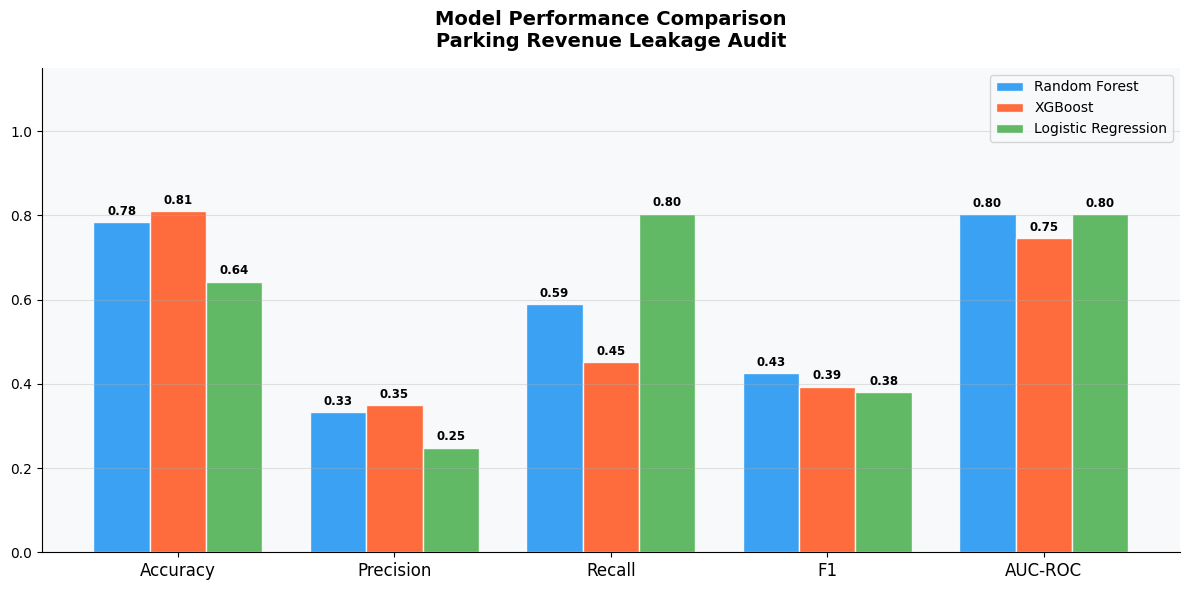

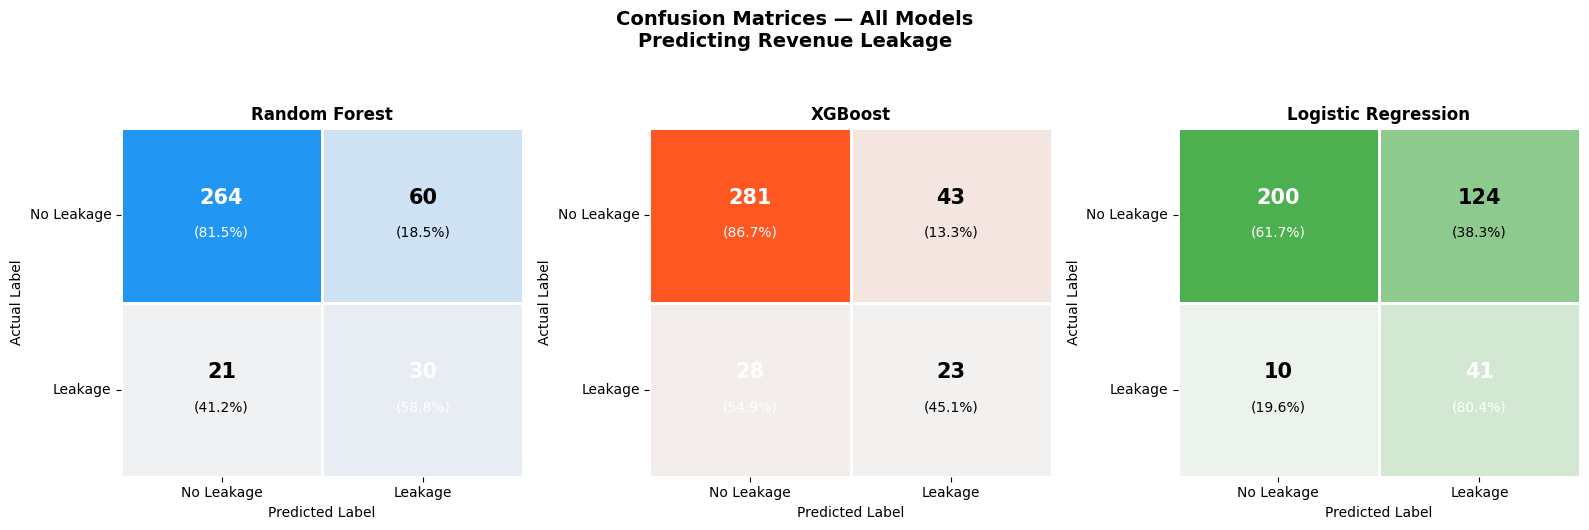

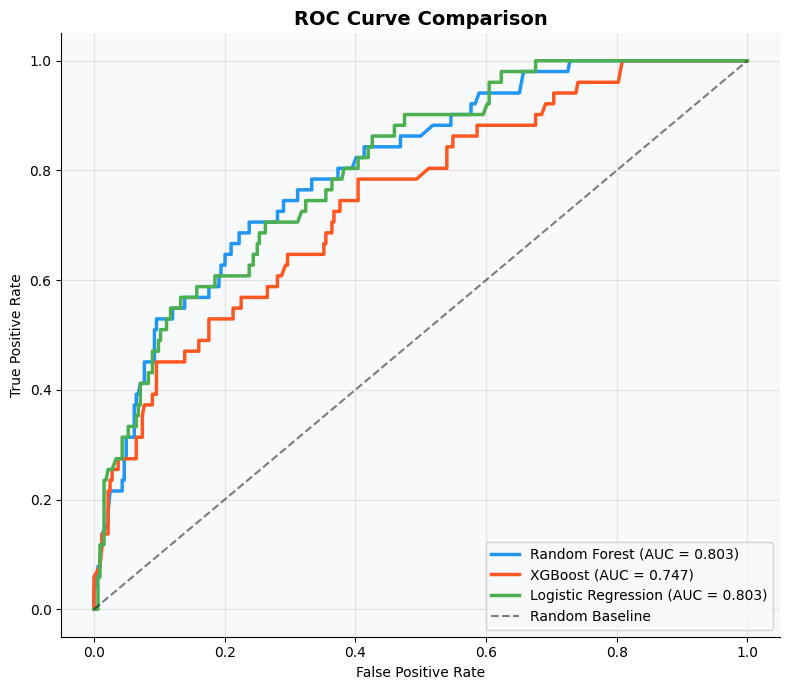

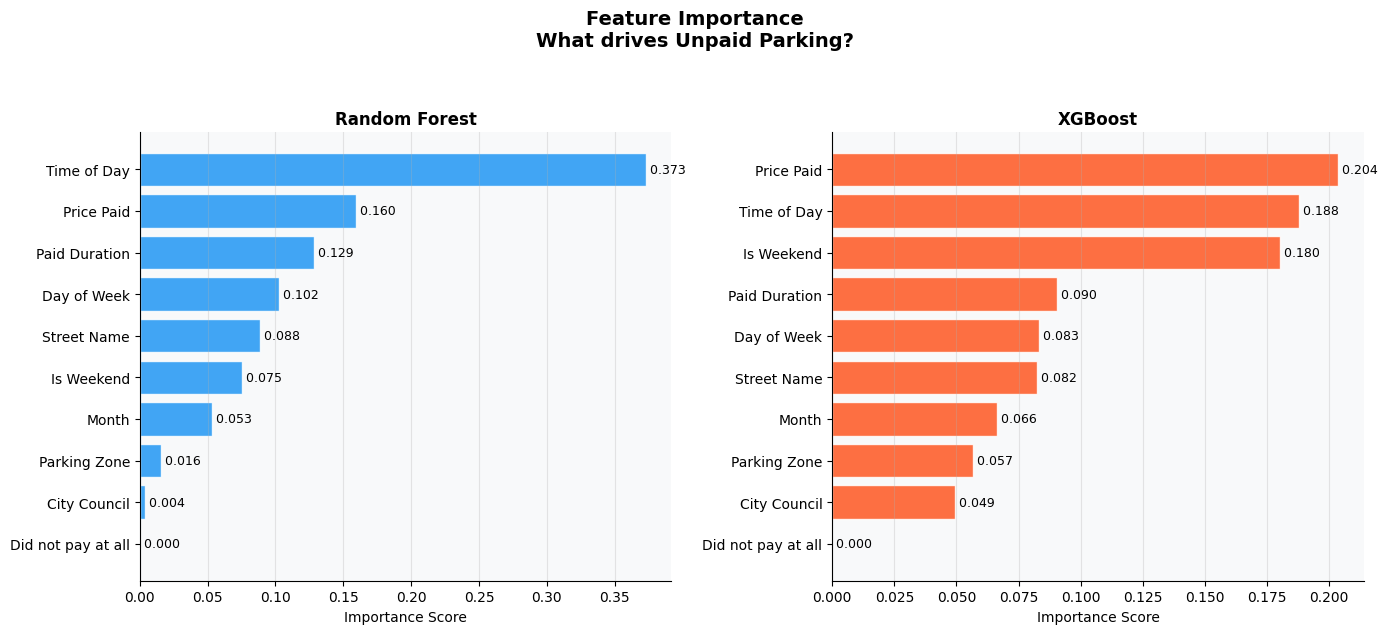


🎉 All 4 plots successfully generated and saved to your folder!


In [ ]:
# ════════════════════════════════════════════════════════════
# 3. GENERATE VISUALIZATIONS
# ════════════════════════════════════════════════════════════

# --- PLOT 1: Model Comparison Bar Chart ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.26

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, color) in enumerate(zip(['Random Forest', 'XGBoost', 'Logistic Regression'], ['rf', 'xgb', 'lr'])):
    vals = summary.loc[name].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=name, color=COLORS[color], alpha=0.88, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Model Performance Comparison\nParking Revenue Leakage Audit', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.savefig('plot_01_model_comparison.png', dpi=150)
plt.show()

# --- PLOT 2: Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — All Models\nPredicting Revenue Leakage', fontsize=14, fontweight='bold', y=1.05)

model_preds = [('Random Forest', y_pred_rf, 'rf'), ('XGBoost', y_pred_xgb, 'xgb'), ('Logistic Regression', y_pred_lr, 'lr')]

for ax, (name, pred, col_key) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm, annot=False, ax=ax, cmap=sns.light_palette(COLORS[col_key], as_cmap=True), linewidths=2, cbar=False)

    for i in range(2):
        for j in range(2):
            text_color = 'white' if cm_pct[i,j] > 50 else 'black'
            ax.text(j + 0.5, i + 0.4, f'{cm[i,j]:,}', ha='center', va='center', fontsize=15, fontweight='bold', color=text_color)
            ax.text(j + 0.5, i + 0.6, f'({cm_pct[i,j]:.1f}%)', ha='center', va='center', fontsize=10, color=text_color)

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')
    ax.set_xticklabels(['No Leakage', 'Leakage'])
    ax.set_yticklabels(['No Leakage', 'Leakage'], rotation=0)

plt.tight_layout()
plt.savefig('plot_02_confusion_matrices.png', dpi=150)
plt.show()

# --- PLOT 3: ROC AUC Curves ---
fig, ax = plt.subplots(figsize=(8, 7))
roc_data = [('Random Forest', y_prob_rf, 'rf'), ('XGBoost', y_prob_xgb, 'xgb'), ('Logistic Regression', y_prob_lr, 'lr')]

for name, prob, col_key in roc_data:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=COLORS[col_key], lw=2.5, label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1.5, alpha=0.5, label='Random Baseline')
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_03_roc_curves.png', dpi=150)
plt.show()

# --- PLOT 4: Feature Importance (RF vs XGB) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance\nWhat drives Unpaid Parking?', fontsize=14, fontweight='bold', y=1.05)

feature_labels_map = {
    'parking_hour': 'Time of Day', 'day_of_week': 'Day of Week', 'is_weekend': 'Is Weekend',
    'month': 'Month', 'paid_duration_min': 'Paid Duration', 'price_rm': 'Price Paid',
    'is_unpaid': 'Did not pay at all', 'council_enc': 'City Council',
    'zone_enc': 'Parking Zone', 'road_name_enc': 'Street Name'
}
labels = [feature_labels_map.get(f, f) for f in feature_cols]

for ax, (name, importances, col_key) in zip(axes, [('Random Forest', rf.feature_importances_, 'rf'), ('XGBoost', xgb.feature_importances_, 'xgb')]):
    feat_df = pd.DataFrame({'Feature': labels, 'Importance': importances}).sort_values('Importance', ascending=True)
    bars = ax.barh(feat_df['Feature'], feat_df['Importance'], color=COLORS[col_key], alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, feat_df['Importance']):
        ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.3f}', va='center', fontsize=9)

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_04_feature_importance.png', dpi=150)
plt.show()

print("\n🎉 All 4 plots successfully generated and saved to your folder!")

### Batch Prediction Method

In [ ]:
!pip install gradio xgboost pandas numpy joblib

In [ ]:
import joblib

# Save the trained XGBoost model to a file
joblib.dump(xgb, 'RF_model.pkl')
print("Model saved successfully as RF_model.pkl")

Model saved successfully as RF_model.pkl


In [ ]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

# Helper function to handle unknown or missing categories safely
def safe_transform(encoder, series):
    # Convert series to strings to match training data
    series_str = series.astype(str)
    # Get the list of categories the encoder learned during training
    known_classes = set(encoder.classes_)
    # If a category is new/unknown, temporarily map it to the first known category (index 0)
    fallback = list(known_classes)[0] if known_classes else "Unknown"
    cleaned_series = series_str.map(lambda x: x if x in known_classes else fallback)
    return encoder.transform(cleaned_series)

# 1. Load the saved Random Forest model and encoders
try:
    model = joblib.load('RF_model.pkl')  # Loads your Random Forest model
    le_council = joblib.load('le_council.pkl')
    le_zone = joblib.load('le_zone.pkl')
    le_road = joblib.load('le_road.pkl')
    print("✅ Model and Encoders loaded successfully.")
except Exception as e:
    print(f"❌ Error loading files: {e}")

# 2. Load the raw matched dataset
df = pd.read_csv('plate_match_verification_results.csv', low_memory=False)

# 3. Re-create the machine learning features
print("Pre-processing features...")
df['parking_start'] = pd.to_datetime(df['started_at'], format='%d/%m/%Y %H:%M', errors='coerce')
df['parking_expiry'] = pd.to_datetime(df['expired_at'], format='%d/%m/%Y %H:%M', errors='coerce')

df['parking_hour'] = df['parking_start'].dt.hour.fillna(-1)
df['day_of_week'] = df['parking_start'].dt.dayofweek.fillna(-1)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month'] = df['parking_start'].dt.month.fillna(-1)

df['paid_duration_min'] = ((df['parking_expiry'] - df['parking_start']).dt.total_seconds() / 60).fillna(0)
df['price_rm'] = df['price'].fillna(0)
df['is_unpaid'] = (df['price_rm'] == 0).astype(int)

# 4. Safe Encoding of text columns (No more crashing on 'Unknown')
print("Encoding location text columns safely...")
df['council_enc'] = safe_transform(le_council, df['council'])
df['zone_enc'] = safe_transform(le_zone, df['zone'])
df['road_name_enc'] = safe_transform(le_road, df['road_name'])

# 5. Define features in exact training order
feature_cols = [
    'parking_hour', 'day_of_week', 'is_weekend', 'month',
    'paid_duration_min', 'price_rm', 'is_unpaid',
    'council_enc', 'zone_enc', 'road_name_enc'
]

X_batch = df[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# 6. Generate predictions using the Random Forest model
print("Generating predictions...")
df['predicted_leakage_prob'] = model.predict_proba(X_batch)[:, 1]

# Apply the custom 30% decision threshold
DECISION_THRESHOLD = 0.30
df['predicted_result'] = df['predicted_leakage_prob'].apply(
    lambda x: "🚨 Predicted Leakage" if x >= DECISION_THRESHOLD else "✅ Predicted No Leakage"
)

# 7. Save the final prediction file for Power BI
output_file = 'predictions_for_powerbi.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"\n🎉 Success! Processed {len(df):,} rows using Random Forest and exported to '{output_file}'")

✅ Model and Encoders loaded successfully.
Pre-processing features...
Encoding location text columns safely...
Generating predictions...

🎉 Success! Processed 1,871 rows using Random Forest and exported to 'predictions_for_powerbi.csv'


In [ ]:
# Export Feature Importances as a CSV
importances = rf.feature_importances_

feature_labels_map = {
    'parking_hour': 'Time of Day',
    'day_of_week': 'Day of Week',
    'is_weekend': 'Is Weekend',
    'month': 'Month',
    'paid_duration_min': 'Paid Duration',
    'price_rm': 'Price Paid',
    'is_unpaid': 'Did not pay at all',
    'council_enc': 'City Council',
    'zone_enc': 'Parking Zone',
    'road_name_enc': 'Street Name'
}
labels = [feature_labels_map.get(f, f) for f in feature_cols]

# Create a clean DataFrame and sort descending
feat_df = pd.DataFrame({
    'Feature': labels,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Export to CSV
feat_df.to_csv('feature_importances.csv', index=False)
print("✅ Saved: 'feature_importances.csv'")

✅ Saved: 'feature_importances.csv'
✅ Saved: 'model_evaluation_metrics.csv'


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create a list to store metrics for all 3 models
comparison_rows = []

# List of models and their respective predictions/probabilities
models_data = [
    ('Random Forest', y_test, y_pred_rf, y_prob_rf),
    ('XGBoost', y_test, y_pred_xgb, y_prob_xgb),
    ('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
]

# Calculate and collect metrics
for model_name, y_true, y_pred, y_prob in models_data:
    comparison_rows.append({'Model': model_name, 'Metric': 'Accuracy', 'Value': accuracy_score(y_true, y_pred)})
    comparison_rows.append({'Model': model_name, 'Metric': 'Precision', 'Value': precision_score(y_true, y_pred, zero_division=0)})
    comparison_rows.append({'Model': model_name, 'Metric': 'Recall', 'Value': recall_score(y_true, y_pred, zero_division=0)})
    comparison_rows.append({'Model': model_name, 'Metric': 'F1 Score', 'Value': f1_score(y_true, y_pred, zero_division=0)})
    comparison_rows.append({'Model': model_name, 'Metric': 'AUC-ROC', 'Value': roc_auc_score(y_true, y_prob)})

# Convert to a DataFrame
comparison_df = pd.DataFrame(comparison_rows)

# Export to a single CSV (BOM enabled for Excel compatibility)
comparison_df.to_csv('model_comparison_metrics.csv', index=False, encoding='utf-8-sig')
print("✅ Saved: 'model_comparison_metrics.csv'")

✅ Saved: 'model_comparison_metrics.csv'
